Parameter fitting
---

Now that we have the trained density ratios, it is time to build the full statistical model

<!-- $$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \underbrace{\frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model} + \lambda_\mathrm{bkg} \cdot \underbrace{\frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model}\bigg]$$ -->

$$-2 \ln \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = -2 \sum_{x_e\in \{x\}} \ln \bigg(\frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \underbrace{\frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model} + \lambda_\mathrm{bkg} \cdot \underbrace{\frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model}\bigg]\bigg)$$

which can be used for the final test statistic:

$$ t_\mu = -2 \big[ \ln L(\mu) - \ln L(\hat{\mu}) \big]$$

where the reference terms have canceled out. 

In this notebook, we will use the `nsbi-common-utils` to build the statistical model and perform fits with the test statistic.  


In [1]:
import os
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import pickle
import matplotlib.pyplot as plt
from nsbi_common_utils.training.utils import load_trained_model


Insert the path to the downloaded dataset (see README for download link)

In [2]:
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Train / inference split

The density ratios must be **trained** and the likelihood **evaluated** on *different* events, otherwise the parameter fit inherits the classifier's overfitting. We split each sample with a fixed seed: the training notebooks (2a, 2b) keep the *training* half and the fitting notebook (3) keeps the *inference* half.

`SPLIT_SEED` and `TRAIN_FRACTION` **must be identical across all three notebooks** — the shared seed is what guarantees the two halves are disjoint. Change `TRAIN_FRACTION` (or pass `n_train=<int>` to `split_train_inference`) to adjust how many events go to training vs. inference.

In [4]:
from utils import split_train_inference

SPLIT_SEED = 0
TRAIN_FRACTION = 0.5  # fraction of each sample used for TRAINING

_, signal = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
_, background = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

print(f"Fitting on {len(signal):,} signal + {len(background):,} background events")

Fitting on 1,000,000 signal + 1,000,000 background events


Get the total yields for the estimation of $\lambda_\mathrm{sig}, \lambda_\mathrm{bkg}$ to be used in the statistical model

In [5]:
TOTAL_YIELD = {}
TOTAL_YIELD["signal"] = signal.weight.sum()
TOTAL_YIELD["background"] = background.weight.sum()

Since we are using a weighted dataset, we also need a weighted sum of log-likelihoods and thus need to extract the weight vector for the data we are fitting

$$-2 \ln L(\mu) = -2 \sum_{x_e\in \{x\}} w_e \cdot \ln \bigg(\frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\bigg]\bigg)$$

In [6]:
asimov_dataset = pd.concat([background, signal], ignore_index=True).astype('float32').copy()
weights_asimov = np.array(asimov_dataset.weight)
PATH_TO_WEIGHTS = "saved_weights/asimov_weight_array.npy"
os.makedirs(os.path.dirname(PATH_TO_WEIGHTS), exist_ok=True)
np.save(PATH_TO_WEIGHTS, weights_asimov)

Features used in the training setup

In [7]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

Set the path to where the estimated density ratios from trained models will be saved, to be later used in the fits

In [8]:
PATH_TO_RATIOS = {}
PATH_TO_RATIOS["signal"] = "saved_ratios_asimov/ratio_SigvsRef.npy"
PATH_TO_RATIOS["background"] = "saved_ratios_asimov/ratio_BkgvsRef.npy"

In [9]:
for path in PATH_TO_RATIOS.values():
    os.makedirs(os.path.dirname(path), exist_ok=True)

Load the trained models, and evaluate on data. For this example, we use the Asimov data only.

A simple call to `nsbi_common_utils.training.utils.predict_with_model` with the path to the saved neural networks is enough to get the predictions.

The networks were trained with the binary cross-entropy loss, so their raw output is the classifier score $\hat{s}(x)$. The density ratio we want is obtained via the monotonic transformation

$$ \hat{r}(x) = \frac{\hat{s}(x)}{1.0 - \hat{s}(x)} $$

**`predict_with_model` applies this transformation for you** and returns the density ratio directly — so do *not* convert its output again (doing so would compute $r/(1-r)$, which is negative wherever $r>1$ and diverges at $r\approx 1$, producing `nan` in the fit).


In [10]:
ensemble_size = 1
ratios = []
for ens_index in range(ensemble_size):
    path_to_saved_scaler = f"models_SigvsRef/model_scaler{ens_index}.bin"
    path_to_saved_model  = f"models_SigvsRef/model{ens_index}.onnx"

    scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

    ratio = nsbi_common_utils.training.utils.predict_with_model(
        asimov_dataset[training_features],
        scaler=scaler,
        model=model,
    )
    ratios.append(ratio)

prediction_ratio = np.mean(np.stack(ratios, axis=0), axis=0)
np.save(PATH_TO_RATIOS["signal"], prediction_ratio)


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [11]:
ensemble_size = 1
ratios = []
for ens_index in range(ensemble_size):
    path_to_saved_scaler = f"models_BkgvsRef/model_scaler{ens_index}.bin"
    path_to_saved_model  = f"models_BkgvsRef/model{ens_index}.onnx"

    scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

    ratio = nsbi_common_utils.training.utils.predict_with_model(
        asimov_dataset[training_features],
        scaler=scaler,
        model=model,
    )
    ratios.append(ratio)

prediction_ratio = np.mean(np.stack(ratios, axis=0), axis=0)
np.save(PATH_TO_RATIOS["background"], prediction_ratio)


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Build a workspace
---

Now its time to build a workspace object, which is a serialization of the statistical model, that can be used to perform parameter fits. 

The following JSON serialization standard has been heavily inspired by the `pyhf` framework by design - allowing future avenues of interoperability.

Key differences:

- a new `type` field has been added to distinguish SBI region from binned regions (e.g. control regions or combination channels)
- the `data` fields now store the total event yield in the SBI region instead of the binned arrays
- the path to the evaluated density ratios on the data is passed to the `ratios` field inside of each sample.

In [12]:
def make_workspace():
    """Toy workspace for this example."""
    return {
        "channels": [{
            "name": "SR",
            "type": "unbinned",
            "weights": PATH_TO_WEIGHTS,
            "samples": [
                {"name": "signal",
                 "data": [TOTAL_YIELD["signal"]],
                 "ratios": PATH_TO_RATIOS["signal"],
                 "modifiers": [{"name": "mu", "type": "normfactor"}]},
                {"name": "background",
                 "data": [TOTAL_YIELD["background"]],
                 "ratios": PATH_TO_RATIOS["background"],
                 "modifiers": []},
            ],
        }],
        # "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                ],
            },
        }],
        "version": "1.0.0",
    }


In [13]:
ws_nsbi = make_workspace()

Pass the workspace to the model API `nsbi_common_utils.models.sbi_parametric_model`, which internally builds the JAX-based model to be used for fitting 

In [14]:
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_nsbi, 
                                                            measurement_to_fit="meas")

Get the hyperparameters

In [15]:
list_params, init_values = model_nsbi.get_model_parameters()
num_unconstrained = model_nsbi.num_unconstrained_param

Pass the model to an inference library - currently using an "in-house" simple API `nsbi_common_utils.inference`, but the longer term goal is that this model can be used with standard fitting frameworks.

In [16]:
inf_nsbi = nsbi_common_utils.inference.inference(
            model_nll=model_nsbi.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained,
            model_grad=model_nsbi.model_grad
        )

Get the global fit results

In [17]:
print("\n" + "="*40)
print(" NSBI FIT RESULTS ")
print("="*40 + "\n")
inf_nsbi.perform_fit(freeze_params=[])


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.566e+07                 │         Nfcn = 20, Ngrad = 1         │
│ EDM = 5.56e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬───────────

Build the $t_\mu$ curve for parameter estimation

In [18]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = inf_nsbi.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0.0, 2.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

Text(0, 1, '$t_\\mu$')

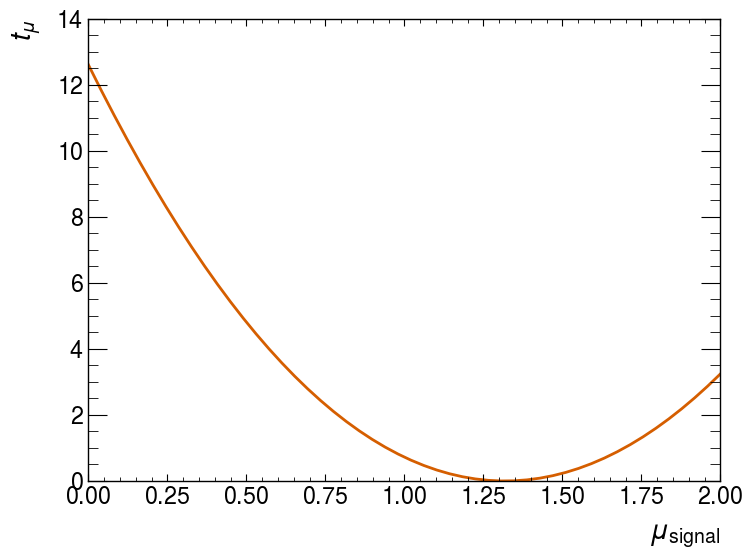

In [19]:
plt.plot(scan_points_nsbi, NLL_value_nsbi)
plt.axis(ymin=0)
plt.xlabel(r"$\mu_\mathrm{signal}$")
plt.ylabel(r"$t_\mu$")

Seeing a bias in the estimator? This is expected in any per-event approach due to the MC noise from limited datasets. 

Try increasing the dataset size for training, generating more data for asimov using instructions on the README, or train larger ensembles.

Disentangling training quality from inference statistics
---

The fit above uses the density ratios *estimated by the neural networks*, so any deviation of $\hat{\mu}$ from 1 mixes two very different sources of error:

1. **Inference-data statistics / MC noise** — the per-event likelihood is evaluated on a *finite* Asimov sample. Even with perfect ratios, $\hat{\mu}$ fluctuates around 1, and its uncertainty $\sigma_\mu$ is essentially set by the (small) signal yield.
2. **Density-ratio estimation error** — the networks only *approximate* the true ratios.

Because this is a toy built from known Gaussian mixtures, we can compute the **exact analytic density ratios** and rerun the identical fit with them. The truth-ratio fit isolates source (1); the gap between the truth and predicted curves isolates source (2).

The mixture definitions live in `utils.py` (the same ones `generate_distributions.py` samples from), so the truth ratios are guaranteed to match the data. Recall the training reference is `background + signal` weighted by physics yields, i.e. as a normalised density

$$ p_\mathrm{ref}(x) = \frac{\lambda_\mathrm{bkg}\, p_\mathrm{bkg}(x) + \lambda_\mathrm{sig}\, p_\mathrm{sig}(x)}{\lambda_\mathrm{bkg} + \lambda_\mathrm{sig}} $$


In [20]:
from utils import background_components, signal_components, mixture_density

# The training reference is background + signal, weighted by physics yields,
# so as a normalised density p_ref = (lam_bkg p_bkg + lam_sig p_sig)/(lam_bkg+lam_sig).
lam_bkg = TOTAL_YIELD["background"]
lam_sig = TOTAL_YIELD["signal"]

# Evaluate the analytic densities on the same Asimov dataset used above
X_asimov = asimov_dataset[training_features].values
p_bkg = mixture_density(X_asimov, background_components())
p_sig = mixture_density(X_asimov, signal_components())
p_ref = (lam_bkg * p_bkg + lam_sig * p_sig) / (lam_bkg + lam_sig)

# The exact density ratios the networks are trying to learn
r_sig_truth = p_sig / p_ref
r_bkg_truth = p_bkg / p_ref

PATH_TO_RATIOS_TRUTH = {
    "signal": "saved_ratios_asimov/ratio_SigvsRef_truth.npy",
    "background": "saved_ratios_asimov/ratio_BkgvsRef_truth.npy",
}
np.save(PATH_TO_RATIOS_TRUTH["signal"], r_sig_truth)
np.save(PATH_TO_RATIOS_TRUTH["background"], r_bkg_truth)

print(f"truth r_sig: min={r_sig_truth.min():.3g}  max={r_sig_truth.max():.3g}  median={np.median(r_sig_truth):.3g}")
print(f"truth r_bkg: min={r_bkg_truth.min():.3g}  max={r_bkg_truth.max():.3g}  median={np.median(r_bkg_truth):.3g}")

truth r_sig: min=0.00266  max=190  median=1
truth r_bkg: min=0.792  max=1  median=1


Build a second workspace identical to the first, but pointing at the truth ratios, and fit it.


In [21]:
def make_workspace_truth():
    """Same workspace as make_workspace(), but with the analytic (truth) ratios."""
    ws = make_workspace()
    ws["channels"][0]["samples"][0]["ratios"] = PATH_TO_RATIOS_TRUTH["signal"]
    ws["channels"][0]["samples"][1]["ratios"] = PATH_TO_RATIOS_TRUTH["background"]
    return ws


ws_truth = make_workspace_truth()
model_truth = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_truth, measurement_to_fit="meas")
list_params_t, init_values_t = model_truth.get_model_parameters()
inf_truth = nsbi_common_utils.inference.inference(
    model_nll=model_truth.model,
    initial_values=init_values_t,
    list_parameters=list_params_t,
    num_unconstrained_params=model_truth.num_unconstrained_param,
    model_grad=model_truth.model_grad,
)

print("\n" + "=" * 40)
print(" TRUTH-RATIO FIT RESULTS ")
print("=" * 40 + "\n")
inf_truth.perform_fit(freeze_params=[])



 TRUTH-RATIO FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.566e+07                 │         Nfcn = 20, Ngrad = 1         │
│ EDM = 5.85e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────

Scan $t_\mu$ for both the truth and predicted ratios over a common range and overlay them.


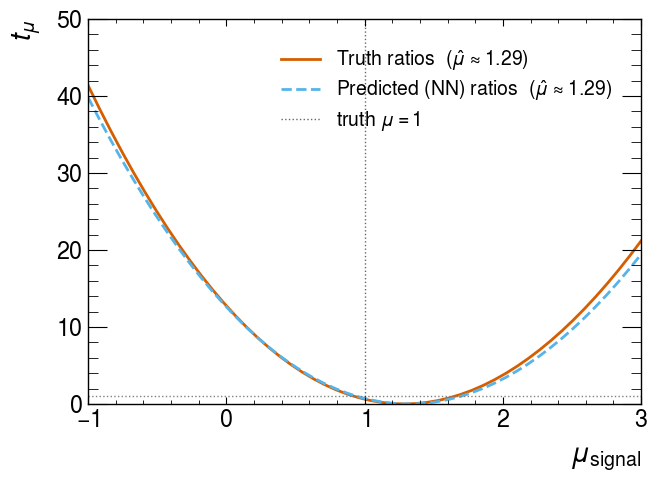

In [22]:
SCAN_RANGE = (-1.0, 3.0)  # widen if either minimum sits outside

scan_truth, tmu_truth, _, _ = inf_truth.perform_profile_scan(
    parameter_name="mu", freeze_params=[], bound_range=SCAN_RANGE,
    fit_strategy=0, doStatOnly=True, size=50,
)
scan_pred, tmu_pred, _, _ = inf_nsbi.perform_profile_scan(
    parameter_name="mu", freeze_params=[], bound_range=SCAN_RANGE,
    fit_strategy=0, doStatOnly=True, size=50,
)

mu_truth = scan_truth[np.argmin(tmu_truth)]
mu_pred = scan_pred[np.argmin(tmu_pred)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_truth, tmu_truth, lw=2, label=f"Truth ratios  ($\\hat{{\\mu}}\\approx{mu_truth:.2f}$)")
ax.plot(scan_pred, tmu_pred, lw=2, ls="--", label=f"Predicted (NN) ratios  ($\\hat{{\\mu}}\\approx{mu_pred:.2f}$)")
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.6, label=r"truth $\mu=1$")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_\mathrm{signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()


**How to read this comparison**

* The offset of the **truth** minimum from $\mu=1$ measures the *inference-data-statistics* (MC-noise) bias alone — the networks play no role in that curve.
* The gap between the **predicted** and **truth** minima measures the additional bias from *imperfect density-ratio estimation* (i.e. training quality).
* The **width** of the curves is $\sigma_\mu$, the intrinsic sensitivity. Here it is dominated by the small signal yield, so it barely shrinks as you add MC events — more data mainly moves the minima *toward* 1 (reduces bias) rather than narrowing the curves.

So: if the truth curve already sits far from 1, you need more inference/training statistics; if truth is close to 1 but predicted is far, the networks need better training (more epochs, larger ensemble, more training events, hyperparameter tuning).


### Systematic Uncertainty Modelling

So far we have left out the nuisance parameter piece of the parameterized density ratio decomposition shown in the slides:

$$\frac{p_s(x|\nu)}{p_s(x)}$$

which would require training density ratios for each "up" and "down" systematic variation. It can be done with additional notebooks and would require a workspace that looks like the following:

In [23]:
SYST_NAME = ""

def make_workspace_with_systematics():
    """Toy workspace for this example."""
    return {
        "channels": [{
            "name": "SR",
            "type": "unbinned",
            "weights": PATH_TO_WEIGHTS,
            "samples": [
                {"name": "signal",
                 "data": [TOTAL_YIELD["signal"]],
                 "ratios": PATH_TO_RATIOS["signal"],
                 "modifiers": [{"name": "mu", "type": "normfactor"},
                                {'name': SYST_NAME,
                                'data': {'hi_data': [TOTAL_YIELD["signal_SYST_NAME_UP"]],
                                    'hi_ratio': PATH_TO_RATIOS["signal_SYST_NAME_UP"],
                                    'lo_data': [TOTAL_YIELD["signal_SYST_NAME_DOWN"]],
                                    'lo_ratio': PATH_TO_RATIOS["signal_SYST_NAME_DOWN"]},
                                'type': 'normplusshape'}]},
                {"name": "background",
                 "data": [TOTAL_YIELD["background"]],
                 "ratios": PATH_TO_RATIOS["background"],
                 "modifiers": [{"name": "mu_bkg", "type": "normfactor"},
                                {'name': SYST_NAME,
                                'data': {'hi_data': [TOTAL_YIELD["background_SYST_NAME_UP"]],
                                    'hi_ratio': PATH_TO_RATIOS["background_SYST_NAME_UP"],
                                    'lo_data': [TOTAL_YIELD["background_SYST_NAME_DOWN"]],
                                    'lo_ratio': PATH_TO_RATIOS["background_SYST_NAME_DOWN"]},
                                'type': 'normplusshape'}]},
            ],
        }],
        # "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                ],
            },
        }],
        "version": "1.0.0",
    }


At the moment, we only have signal strength measurement support due to the pyhf-like structure of the serialization. Work ongoing with Ragansu Chakkapai to allow for intereference-type measurements.